Let's break this down step-by-step for both PCA and clustering, ensuring we take into account the partial or full duplication of rows in your dataset.

### 1. **Using PCA with Sample Weights**:

Since your rows represent unique locations in space, but some columns have repeated values, you can adjust the weight of each row based on its duplication. This will allow the PCA to give more importance to the repeated rows, capturing the underlying structure without removing valuable data.

**Approach**:
- Compute the frequency of each row or group of rows.
- Use these frequencies as weights for the PCA.


In this example:
- We compute the frequency of rows using `groupby` and assign it as a weight for PCA.
- We standardize the data because PCA is sensitive to scale.
- PCA is then applied with the computed sample weights.

### 2. **Clustering after PCA**:

Once you have reduced the dimensionality with PCA, you can cluster the data. Here, you'll still need to account for the weights or the duplication of rows in the clustering algorithm.

You can use clustering algorithms that support `sample_weight`, such as `KMeans`, to give more importance to rows with higher frequencies (duplicates).

Here’s an example using `KMeans` after applying PCA:



### Key Takeaways:
- **PCA with sample weights**: This approach helps account for duplicated rows, giving more weight to them during dimensionality reduction.
- **Clustering**: You can use clustering algorithms such as KMeans and DBSCAN that support `sample_weight` or adapt their parameters to handle the effect of repeated rows.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Example dataset with duplicate rows
data = {
    'feature1': [1, 2, 2, 4, 5, 5, 5],
    'feature2': [3, 3, 3, 6, 7, 7, 7],
    'feature3': [1, 1, 1, 3, 5, 5, 5]
}
df = pd.DataFrame(data)

# Step 1: Count duplicate rows
df_counts = df.value_counts().reset_index(name='count')

# Step 2: Extract features and sample weights
X = df_counts.drop(columns='count')
weights = df_counts['count']

In [32]:
print(df)
print(X)

   feature1  feature2  feature3
0         1         3         1
1         2         3         1
2         2         3         1
3         4         6         3
4         5         7         5
5         5         7         5
6         5         7         5
   feature1  feature2  feature3
0         5         7         5
1         2         3         1
2         1         3         1
3         4         6         3


In [ ]:
# Step 3: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

[[ 1.26491106  1.26025208  1.50755672]
 [-0.63245553 -0.98019606 -0.90453403]
 [-1.26491106 -0.98019606 -0.90453403]
 [ 0.63245553  0.70014004  0.30151134]]


In [ ]:
# Step 4: Weight the data by multiplying each row by its weight
weights = np.array(weights)
X_weighted = X_scaled * weights[:, np.newaxis]

In [ ]:
# Step 4: Perform PCA
pca = PCA()
pca_result = pca.fit_transform(X_weighted)

# Step 5: Show results
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nPCA components:")
print(pca.components_)


Explained variance ratio:
[0.97913332 0.01455432 0.00631236]

PCA components:
[[ 0.54009174  0.59139485  0.59879299]
 [-0.44929529 -0.39900853  0.79932843]
 [ 0.71164222 -0.70074555  0.05020971]]


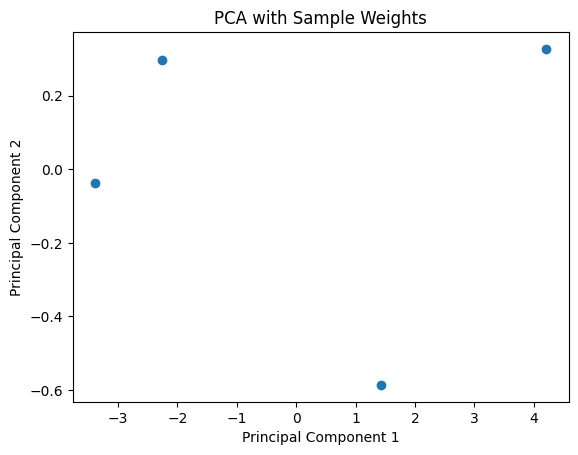

In [ ]:
# Step 4.1: Visualize PCA result (optional)
import matplotlib.pyplot as plt

plt.scatter(pca_result[:, 0], pca_result[:, 1])
plt.title('PCA with Sample Weights')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

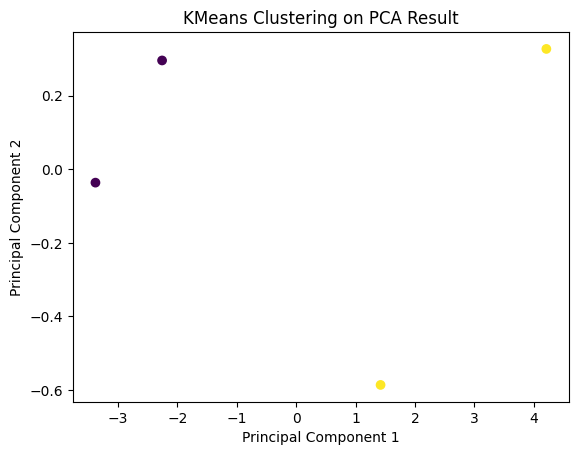

In [ ]:
# Step 5: Perform KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(pca_result, sample_weight=weights)

# Step 5.1: Plot the clustering result
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=kmeans.labels_)
plt.title('KMeans Clustering on PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()
